In [1]:
import numpy as np
import jieba
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer
from bertopic.vectorizers import ClassTfidfTransformer
from transformers.pipelines import pipeline
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer

C:\Python\envs\LYK\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
with open(r"C:\Users\Lyk\Desktop\黑神话悟空-数据\中文评论\9.0-Final\中文评论-Final纯文本.txt", 'r', encoding='utf-8') as file:
  docs = file.readlines()
print('条数: ', len(docs))
print('预览第一条: ', docs[0])

条数:  307621
预览第一条:  要做钟馗了，何年何月才能玩到dlc或者2啊



In [3]:
stopwords_path = r"C:\Users\Lyk\Desktop\黑神话ldabertopic\词典\中文停用词.txt"
with open(stopwords_path, "r", encoding="utf-8") as f:
    chinese_stopwords = [line.strip() for line in f if line.strip()]
print(f"加载停词数量: {len(chinese_stopwords)}")
print(chinese_stopwords[:10])  

加载停词数量: 905
["'", '＇', '-', '--', '－', '－－', '—', '——', '———', '———']


In [4]:
professional_dict_path = r"C:\Users\Lyk\Desktop\黑神话ldabertopic\词典\中文专业词典.txt"
with open(professional_dict_path, "r", encoding="utf-8") as f:
    for line in f:
        word = line.strip()
        if word:
            jieba.add_word(word)
print("专业词典已加载到jieba")

Building prefix dict from the default dictionary ...
Loading model from cache C:\Users\Lyk\AppData\Local\Temp\jieba.cache
Loading model cost 0.672 seconds.
Prefix dict has been built successfully.


专业词典已加载到jieba


In [5]:
def tokenize_zh(text):
    words = jieba.lcut(text)
    # 过滤掉停用词和单字符词
    words = [word for word in words if word not in chinese_stopwords and len(word) > 1]
    return words

In [6]:
embedding_model = pipeline("feature-extraction", model="sentence-transformers/paraphrase-multilingual-mpnet-base-v2") 
embeddings = np.load(r"C:\Users\Lyk\Desktop\黑神话悟空-数据\中文评论\中文词向量\emb(mpnet-base-v2).npy") 
print(embeddings.shape)


umap_model = UMAP(
  n_neighbors= 15,
  n_components=5,
  min_dist=0.0,
  metric='cosine',
  random_state=42 
)


hdbscan_model = HDBSCAN(
  min_cluster_size= 150,
  min_samples = 150,
  metric='euclidean', 
  cluster_selection_method='eom',
  prediction_data=False
)

vectorizer_model = CountVectorizer(
    tokenizer=tokenize_zh
)

ctfidf_model = ClassTfidfTransformer()

Device set to use cuda:0


(307621, 768)


In [7]:
from bertopic.representation import MaximalMarginalRelevance
representation_model = MaximalMarginalRelevance(diversity=0.3)

topic_model = BERTopic(
  embedding_model=embedding_model,
  umap_model=umap_model,
  hdbscan_model=hdbscan_model,
  vectorizer_model=vectorizer_model,
  ctfidf_model=ctfidf_model,
  top_n_words=30,
  calculate_probabilities= False,
  representation_model=representation_model
)

topics, probs = topic_model.fit_transform(docs, embeddings=embeddings)
topic_info = topic_model.get_topic_info()
topic_info

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


,Topic,Count,Name,Representation,Representative_Docs
0,-1,168144,-1_游戏_剧情_战斗_悟空,"[游戏, 剧情, 战斗, 悟空, 美术, 国产, 中国, 地图, 动画, 西游记]",[虽然第一时间买了游戏，但是因为各种自己的原因导致今天才通关一周目双结局。怎么说呢，这是我玩...
1,0,20136,0_地图_空气墙_探索_地图设计,"[地图, 空气墙, 探索, 地图设计, 小地图, 设计, 指引, 很多, 第六章, 体验]",[缺点也确实是有的，首先是地图设计，大部分地图其实路线并没有大的问题，真正的问题在于有些地方...
2,1,17831,1_boss_攻击_技能_战斗,"[boss, 攻击, 技能, 战斗, 敌人, 玩家, 劈棍, 武器, boss战, 棍法]",[3. 妖魔鬼怪的多样挑战：游戏中的敌人种类繁多，每个敌人都有其独特的攻击模式和能力，玩家需...
3,2,9321,2_画面_音乐_美术_剧情,"[画面, 音乐, 美术, 剧情, 精美, 打斗, 故事, 好玩, 风景, 动画]","[画面音乐战斗都非常优秀，好评\n, 画质，剧情，音乐，打斗都是顶级\n, 画面剧情音乐战斗..."
4,3,6786,3_小时_二周目_一周目_三周目,"[小时, 二周目, 一周目, 三周目, 周目, 打完, 全收集, 终于, 游戏, 60]","[真的好玩，美术也好，我已经二周目了，奔全成就去打\n, 60小时一周目通关，二周目开始看攻..."
...,...,...,...,...,...
74,73,168,73_梦想_大圣梦_小时候_儿时,"[梦想, 大圣梦, 小时候, 儿时, 童年, 英雄, 幻想, 无所不能, 心中, 孙悟空]","[非常棒的游戏，当大圣一定是每个孩子小时候的梦想吧，游科让我实现了这个梦想。\n, 实现了儿..."
75,74,168,74_10_评分_8.5_评价,"[10, 评分, 8.5, 评价, 游戏, 9.5, 分数, 好评, 质量, 全成就]",[是因为什么♂♀$成分才高分懂都懂。 作为一个游戏喷子，从自己想喷的点说说评分。 美术：10...
76,75,162,75_里程碑_越来越_国内_第一步,"[里程碑, 越来越, 国内, 第一步, 巅峰, 崛起, 厂商, 技术, 里程碑式, 优质]",[国产单机的里程碑，虽然在故事等方面有瑕疵，但是瑕不掩瑜。希望后续会有更多的优质国产单机\n...
77,76,157,76_黑猴_地图设计_迷路_探索,"[黑猴, 地图设计, 迷路, 探索, 问题, 大量, 小地图, 边界, 让玩家, 路线]",[黑猴的空气墙近来已经被骂烂了，这里不再吐槽，但为何几乎每个相关游戏都有的空气墙设定只有黑猴...


In [11]:
new_topics = topic_model.reduce_outliers(
  docs,
  topics,
  strategy="embeddings",
  embeddings=embeddings, 
  threshold=0.55
)

topic_model.update_topics(docs, topics=new_topics, vectorizer_model=vectorizer_model) 
topic_info = topic_model.get_topic_info()
topic_info

,Topic,Count,Name,Representation,Representative_Docs
0,-1,78412,-1_游戏_剧情_战斗_设计,"[游戏, 剧情, 战斗, 设计, boss, 玩家, 体验, 黑神话, 问题, 很多]",[虽然第一时间买了游戏，但是因为各种自己的原因导致今天才通关一周目双结局。怎么说呢，这是我玩...
1,0,22102,0_地图_空气墙_探索_地图设计,"[地图, 空气墙, 探索, 地图设计, 引导, 迷路, 地方, 问题, 小地图, 设计]",[缺点也确实是有的，首先是地图设计，大部分地图其实路线并没有大的问题，真正的问题在于有些地方...
2,1,18927,1_boss_攻击_技能_战斗,"[boss, 攻击, 技能, 战斗, 锁定, 伤害, 动作, 闪避, 设计, 敌人]",[3. 妖魔鬼怪的多样挑战：游戏中的敌人种类繁多，每个敌人都有其独特的攻击模式和能力，玩家需...
3,2,9914,2_画面_音乐_美术_剧情,"[画面, 音乐, 美术, 剧情, 打斗, 精美, 战斗, 顶级, 故事, 画质]","[画面音乐战斗都非常优秀，好评\n, 画质，剧情，音乐，打斗都是顶级\n, 画面剧情音乐战斗..."
4,3,9104,3_小时_一周目_二周目_全成就,"[小时, 一周目, 二周目, 全成就, 通关, 三周目, 周目, 成就, 打完, 结局]","[真的好玩，美术也好，我已经二周目了，奔全成就去打\n, 60小时一周目通关，二周目开始看攻..."
...,...,...,...,...,...
74,73,746,73_小时候_童年_梦想_儿时,"[小时候, 童年, 梦想, 儿时, 大圣梦, 西游记, 齐天大圣, 长大, 幻想, 孩子]","[非常棒的游戏，当大圣一定是每个孩子小时候的梦想吧，游科让我实现了这个梦想。\n, 实现了儿..."
75,74,360,74_10_评分_8.5_情怀,"[10, 评分, 8.5, 情怀, 9.5, 评价, 满分, 个人, 0.5, 综合]",[是因为什么♂♀$成分才高分懂都懂。 作为一个游戏喷子，从自己想喷的点说说评分。 美术：10...
76,75,227,75_666_单机_国产_棒棒,"[666, 单机, 国产, 棒棒, 66, 支持, 里程碑, 越来越, 希望, 作品]",[国产单机的里程碑，虽然在故事等方面有瑕疵，但是瑕不掩瑜。希望后续会有更多的优质国产单机\n...
77,76,583,76_地图_黑猴_地图设计_空气墙,"[地图, 黑猴, 地图设计, 空气墙, 设计, 黛玉黑, 红楼, 迷路, 地方, 探索]",[黑猴的空气墙近来已经被骂烂了，这里不再吐槽，但为何几乎每个相关游戏都有的空气墙设定只有黑猴...


In [12]:
topic_model.reduce_topics(docs, nr_topics= "auto")
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,78412,-1_游戏_剧情_战斗_boss,"[游戏, 剧情, 战斗, boss, 设计, 玩家, 体验, 黑神话, 问题, 很多]",[总的来说是一款好玩的游戏，值得推荐。画面优秀，boss设计不错，打斗流畅，整体可玩性强内容...
1,0,22102,0_地图_空气墙_探索_地图设计,"[地图, 空气墙, 探索, 地图设计, 引导, 迷路, 地方, 问题, 设计, 小地图]","[好玩就是没地图，太容易迷路了，我现实中都找不到路，打到第三章阴间地图了\n, 无论动作还是..."
2,1,18927,1_boss_攻击_战斗_技能,"[boss, 攻击, 战斗, 技能, 锁定, 动作, 设计, 伤害, 闪避, 敌人]",[终于通关了，谈谈感受， 先说boss的难度问题，我认为boss设计的很巧妙，每个boss的...
3,2,14992,2_3a_国产_第一款_大作,"[3a, 国产, 第一款, 大作, 游戏, 支持, 希望, 国内, 第一个, 中国]","[支持国产3a游戏，好玩的里\n, 第一款国产3a大作必须支持\n, 国产3a大作非常棒的体..."
4,3,13403,3_黑猴_猴子_猴哥_老猴子,"[黑猴, 猴子, 猴哥, 老猴子, 大圣, 游戏, 猿神, 最后, 游科, 孙悟空]","[好玩，这只猴子又一次救了国内游戏\n, 一周目双结局，虽然个人对黑猴的期望值很高，但还是超..."
5,4,11884,4_黑神话_悟空_西游记_剧情,"[黑神话, 悟空, 西游记, 剧情, 故事, 原著, 孙悟空, 斗战神, 大圣, 西游]",[我感觉非常奇怪的一点就是，早些年大家都很喜欢这种改编西游，比如大话西游，悟空传等等，现在又...
6,5,11139,5_第六章_第五章_第四章_剧情,"[第六章, 第五章, 第四章, 剧情, 第三章, 前三章, 两章, 四章, 第二章, 结局]",[第一章：7分 第二章：8分，漫天黄沙地图迷路-1分，7分 第三章：10分，浮屠界爬塔-2分...
7,6,10634,6_游戏_游戏科学_希望_国产,"[游戏, 游戏科学, 希望, 国产, 感谢, 玩家, 期待, 一款, dlc, 游科]","[游戏科学，未来可期。\n, 感谢游戏科学为玩家创作出这一款艺术品，期待dlc\n, 虽然不..."
8,7,10572,7_好玩_豪玩_爱玩_dlc,"[好玩, 豪玩, 爱玩, dlc, 喜欢, 真好玩, 希望, 难度, 游戏, 很爽]","[好玩，特别喜欢，敲爱玩！！！\n, 很好玩特别好玩。国产的光\n, 不错好玩好玩好玩，我很..."
9,8,9914,8_画面_音乐_美术_剧情,"[画面, 音乐, 美术, 剧情, 战斗, 打斗, 精美, 顶级, 故事, 好玩]","[真的好玩，剧情豪，画面豪\n, 战斗，爽！美术音乐，绝！\n, 非常不错，剧情个人不喜欢，..."


100%|██████████████████████████████████████████████████████████████████████████████████| 54/54 [00:01<00:00, 40.61it/s]


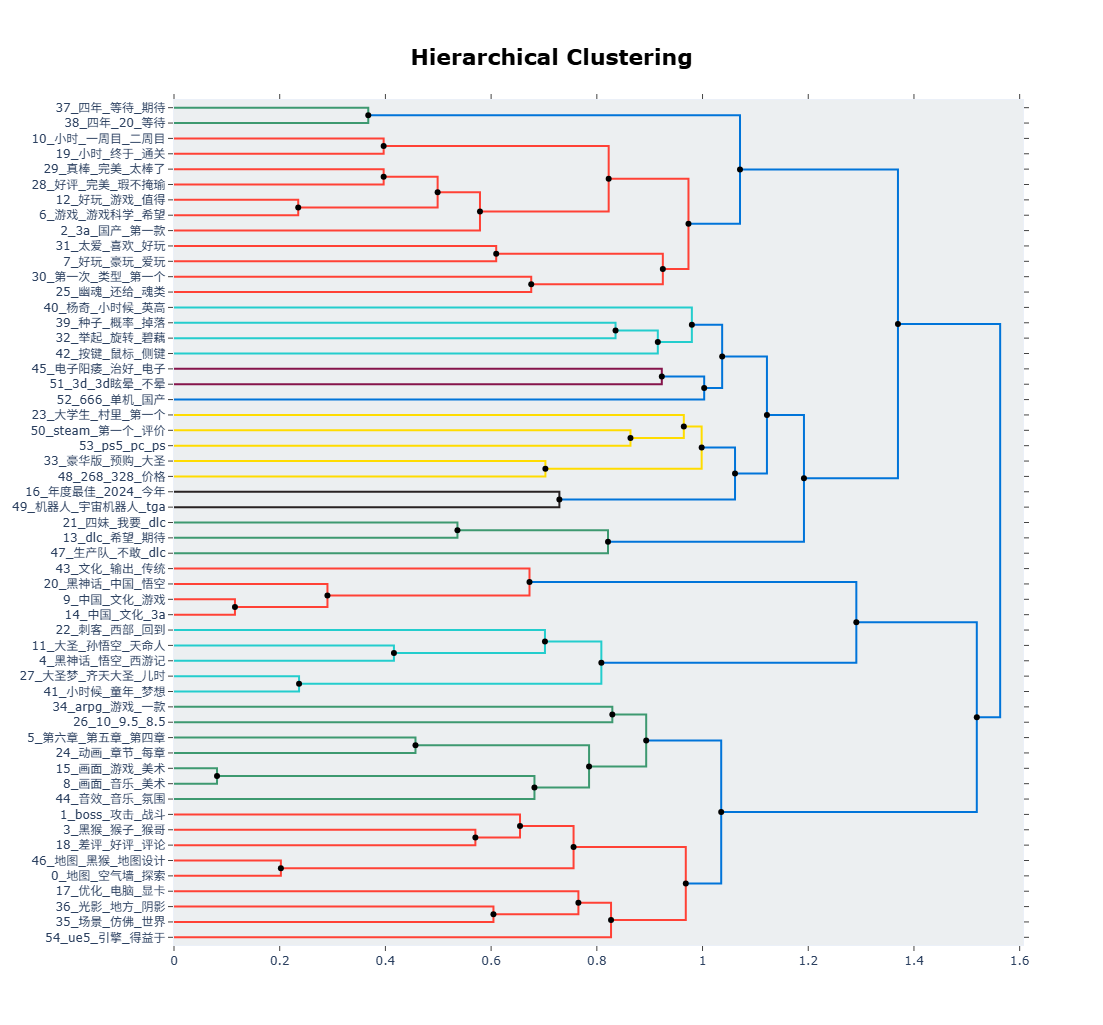

In [13]:
hierarchical_topics = topic_model.hierarchical_topics(docs)
topic_model.visualize_hierarchy(hierarchical_topics=hierarchical_topics)

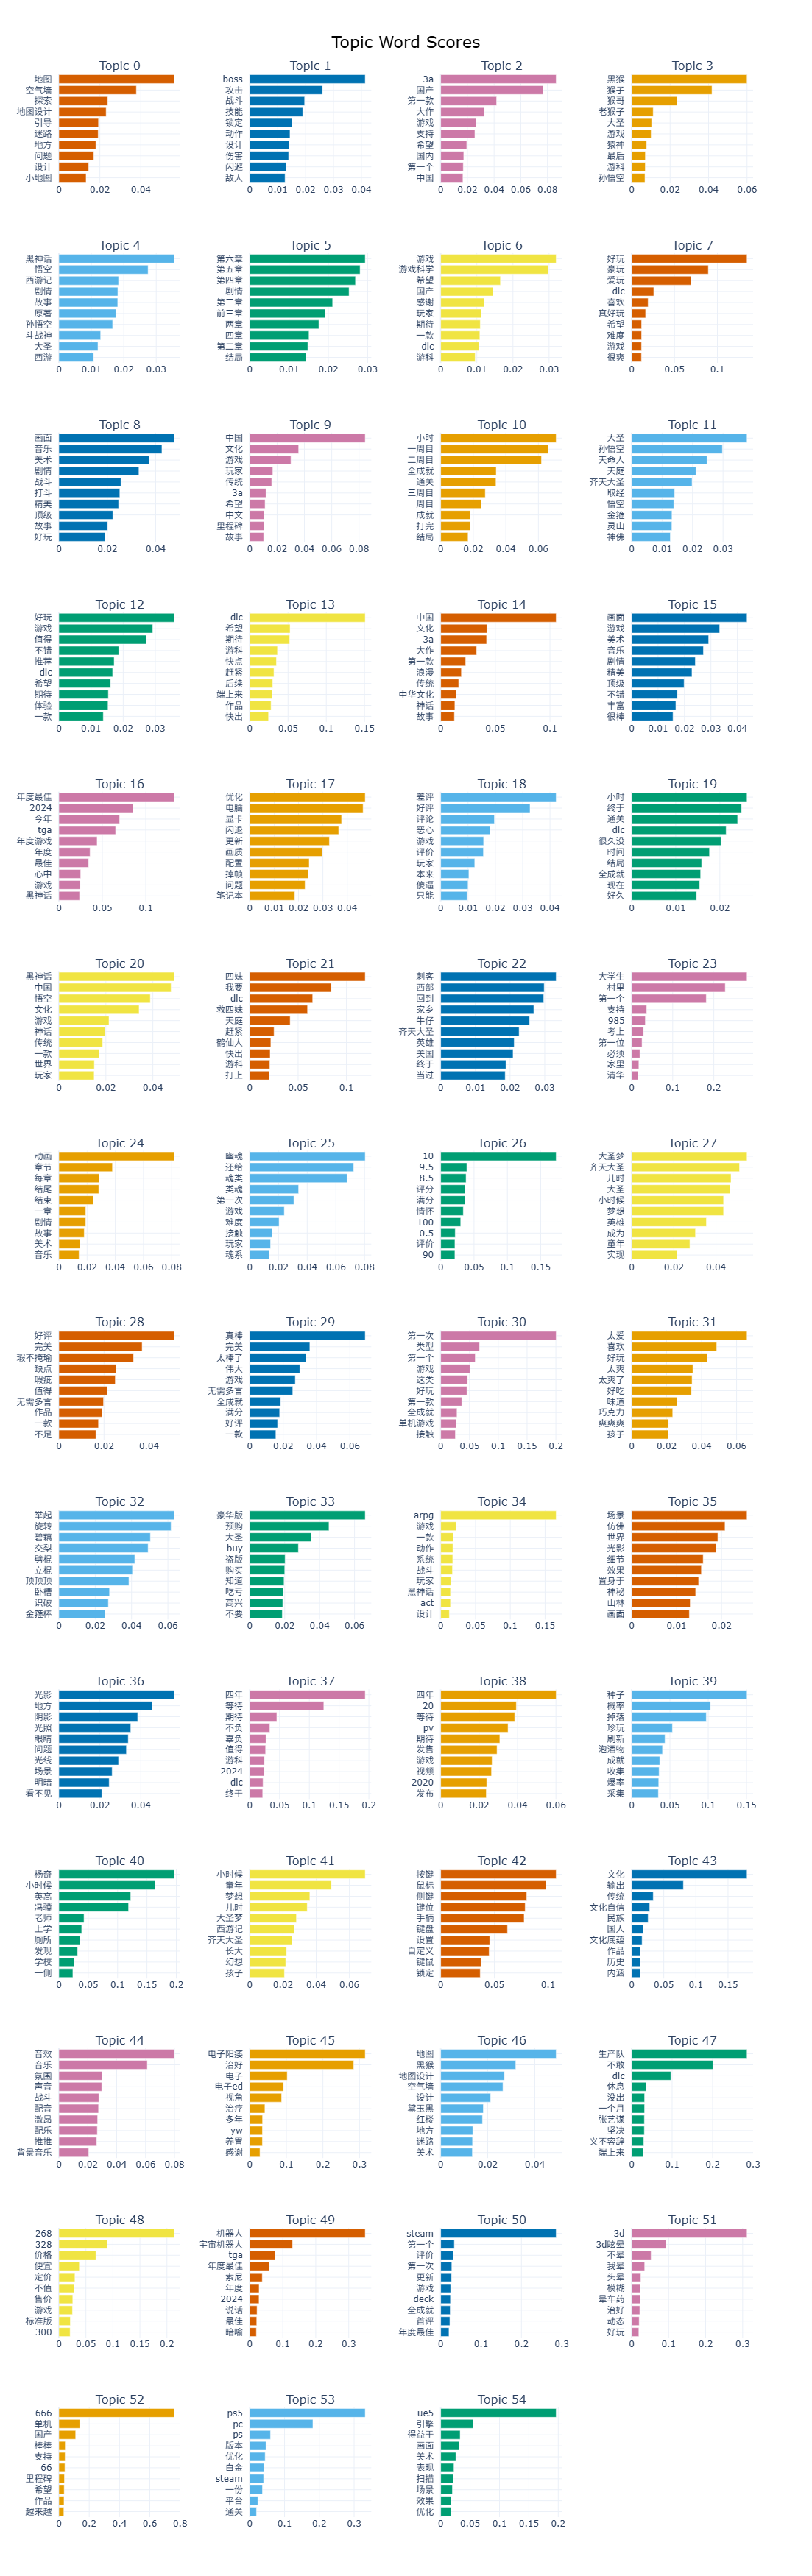

In [14]:
fig = topic_model.visualize_barchart(top_n_topics= 55, n_words = 10)
fig.show()
fig.write_html(r"C:\Users\Lyk\Desktop\黑神话悟空-数据\中文评论\主题词图.html")

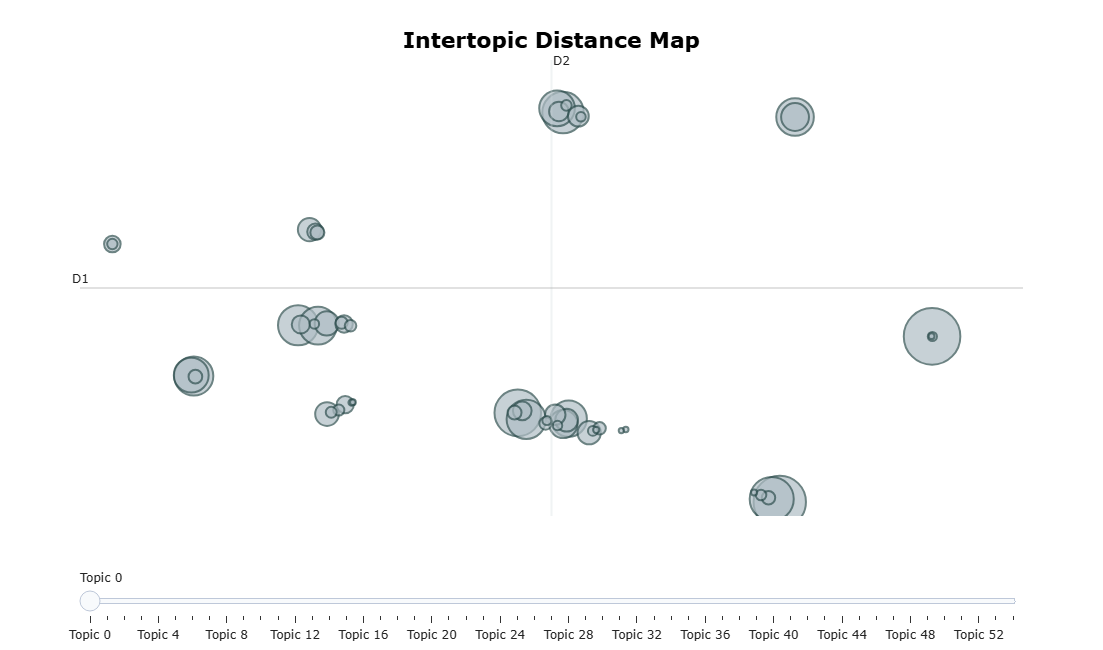

In [15]:
fig = topic_model.visualize_topics()
fig.show()
fig.write_html(r"C:\Users\Lyk\Desktop\黑神话悟空-数据\中文评论\气泡图.html")

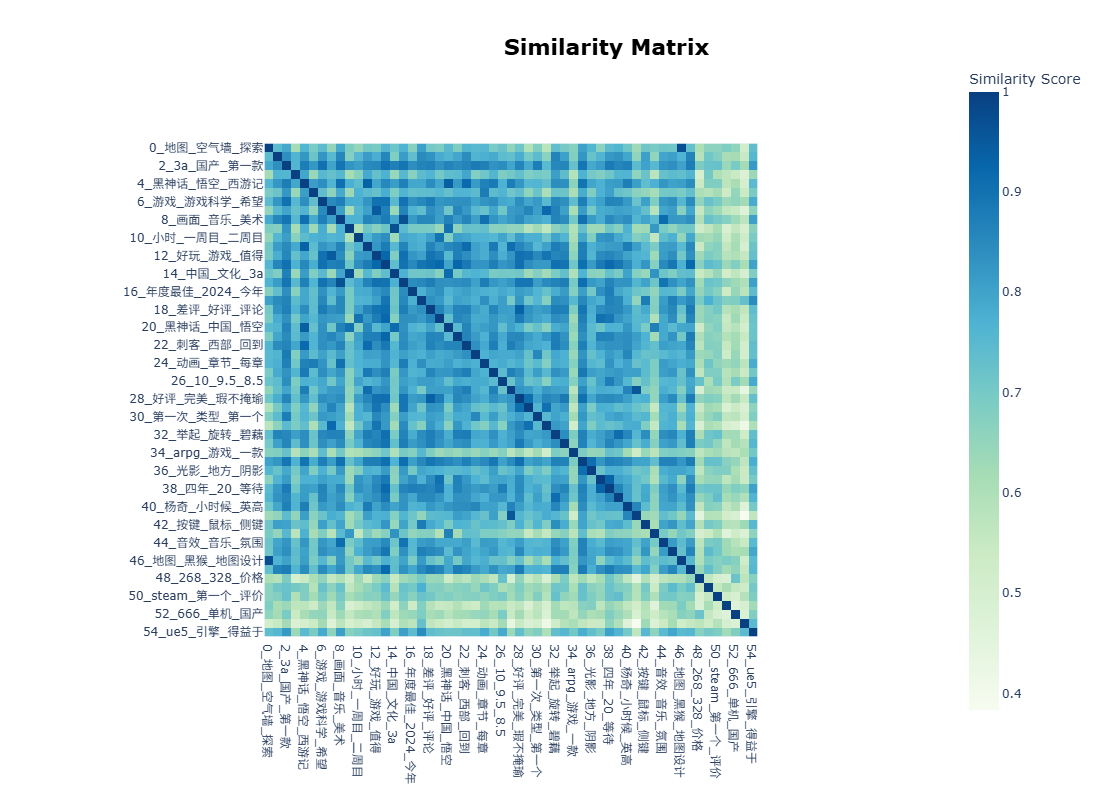

In [16]:
pic = topic_model.visualize_heatmap()
pic.write_html(r"C:\Users\Lyk\Desktop\黑神话悟空-数据\中文评论\主题相似度图.html")
pic.show()